In [5]:
import sys
from pathlib import Path

project_root = Path().resolve().parents[1]  # adjust if needed
sys.path.append(str(project_root))

In [6]:
from pathlib import Path
import random
import matplotlib.pyplot as plt
from tqdm import tqdm

import torch
from torch.utils.data import DataLoader

from src.brain_transforms import get_spatial_transform_list 
from src.data import DicomDataset

In [7]:
data_dir = Path('/data/vision/polina/users/marcusbl/data')

dataset = DicomDataset(data_dir)
dataset.set_norm(mask_method = 'stack')

Loading People Data:   0%|          | 0/30 [00:00<?, ?it/s]

Loading People Data: 100%|██████████| 30/30 [00:05<00:00,  5.13it/s]


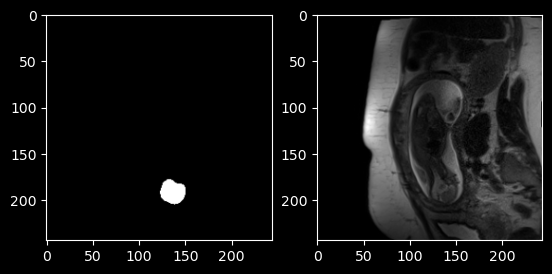

In [11]:
idx = 51

full = dataset[idx][0]

mask = full[1]
scan = full[0]

fig, ax = plt.subplots(ncols = 2)
ax[0].imshow(mask, vmin=0, vmax=1, cmap='grey')
ax[1].imshow(scan, cmap="gray")


bad


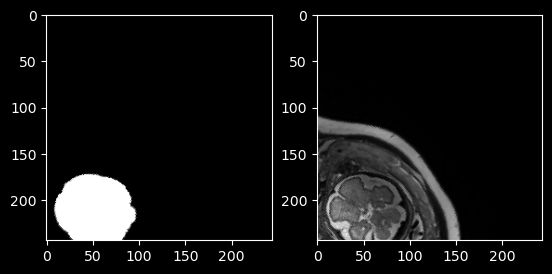

In [9]:
augs = get_spatial_transform_list(trans_perc = 0.40, translate_far = True)
# augs = get_spatial_transform_list(trans_perc = 0.20, translate_far = False)

for transform in augs:
    new_full = transform(full)
    if transform.mask_moves_outside(mask):
        print('bad')

new_mask = new_full[1]
new_scan = new_full[0]

fig, ax = plt.subplots(ncols = 2)
ax[0].imshow(new_mask, vmin=0, vmax=1, cmap='grey')
ax[1].imshow(new_scan, cmap="gray")

In [ ]:
dataloader = DataLoader(dataset, batch_size = 32)

all_rows = []
all_cols = []
distances_to_center = []
all_bad_idxs = []

# around 1 minute
for batch_i, (data, label) in enumerate(tqdm(dataloader)):
    batch_idx, rows, cols = torch.where(data[:, 1, :, :] > 0)

    # distance to center
    dist = torch.sqrt((rows - 122)**2 + (cols - 122)**2)

    # prepare output (one value per batch)
    B = data.shape[0]
    min_dist_per_batch = torch.full((B,), float('inf'), device=data.device)

    # reduce per batch
    min_dist_per_batch.scatter_reduce_(
        0,
        batch_idx,
        dist,
        reduce="amin"
    )

    distances_to_center.extend(min_dist_per_batch.tolist())

    for i in range(B):
        if min_dist_per_batch[i] > 50:
            dataset_idx = batch_i * dataloader.batch_size + i
            print(f"Dataset idx {dataset_idx} exceeded distance: {min_dist_per_batch[i].item():.2f}")

    all_rows.extend(rows.tolist())
    all_cols.extend(cols.tolist())


  1%|          | 2/229 [00:00<01:35,  2.37it/s]

Dataset idx 51 exceeded distance: 56.57
Dataset idx 52 exceeded distance: 56.22
Dataset idx 53 exceeded distance: 54.33
Dataset idx 54 exceeded distance: 54.45
Dataset idx 55 exceeded distance: 54.78
Dataset idx 56 exceeded distance: 56.30
Dataset idx 57 exceeded distance: 56.04
Dataset idx 58 exceeded distance: 51.01
Dataset idx 59 exceeded distance: 50.16
Dataset idx 60 exceeded distance: 50.09
Dataset idx 61 exceeded distance: 53.49
Dataset idx 63 exceeded distance: 52.55


  1%|▏         | 3/229 [00:01<01:53,  1.99it/s]

Dataset idx 64 exceeded distance: 50.29
Dataset idx 65 exceeded distance: 52.20
Dataset idx 66 exceeded distance: 54.12


  4%|▍         | 9/229 [00:04<01:41,  2.16it/s]


KeyboardInterrupt: 

In [ ]:
rows = torch.tensor(all_rows)
cols = torch.tensor(all_cols)

H = 244
W = 244

flat_idx = rows * W + cols
hist = torch.bincount(flat_idx, minlength=H * W).reshape(H, W)

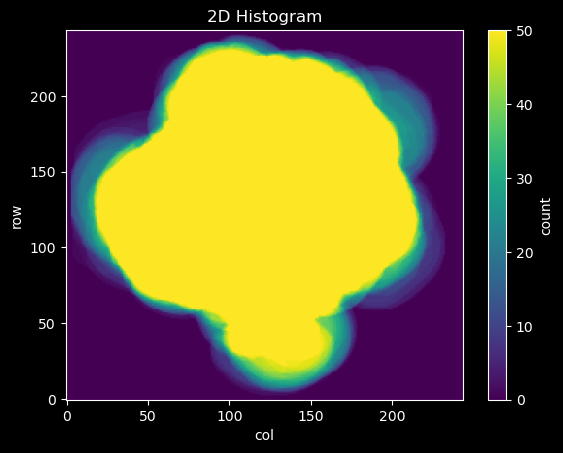

In [ ]:
plt.imshow(hist.cpu(), aspect='auto', vmin = 0, vmax = 50)
plt.colorbar(label="count")
plt.xlabel("col")
plt.ylabel("row")
plt.gca().invert_yaxis()
plt.title("2D Histogram")
plt.show()

(array([5333.,  362.,  320.,  332.,  254.,  284.,  199.,  131.,   83.,
          22.]),
 array([ 0. ,  7.5, 15. , 22.5, 30. , 37.5, 45. , 52.5, 60. , 67.5, 75. ]),
 <BarContainer object of 10 artists>)

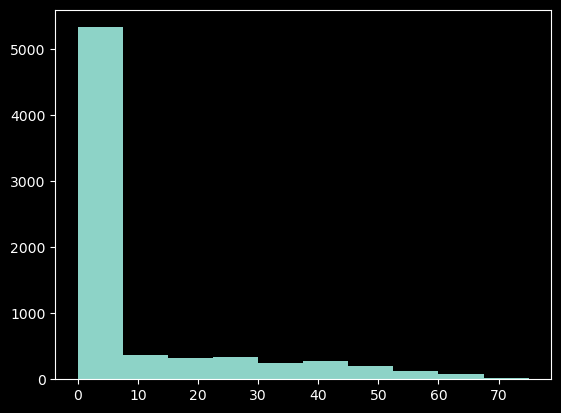

In [ ]:
plt.hist(distances_to_center)

In [ ]:
import pandas as pd

In [ ]:
s = pd.Series(distances_to_center)
stats = s.describe(include='95%')
stats

count    7320.000000
mean        8.853171
std        16.189315
min         0.000000
25%         0.000000
50%         0.000000
75%        10.049875
max        75.000000
dtype: float64

In [ ]:
s.describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95, 0.99])

count    7320.000000
mean        8.853171
std        16.189315
min         0.000000
5%          0.000000
25%         0.000000
50%         0.000000
75%        10.049875
95%        47.927029
99%        61.840439
max        75.000000
dtype: float64